In [29]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import json
import ast
import re

**Load the generated CSV files**

In [37]:
residue_df = pd.read_csv("/home/postyr/Assessing-AI-Scoring-Accuracy-for-De-Novo-Proteins/results/Protenix/protenix_compiled.csv")
# columns: complex_id, chain, residue_name, residue_id, icode, plddt

adaptyv_bio_df = pd.read_csv("/home/postyr/Assessing-AI-Scoring-Accuracy-for-De-Novo-Proteins/results/AdaptyvBio/result_summary.csv")
# columns: name, binding_strength, binding, expression, pae_interaction, design_models.


**Distributions of pLDDT**

Check overall prediction confidence across the 400 complexes and per chain.

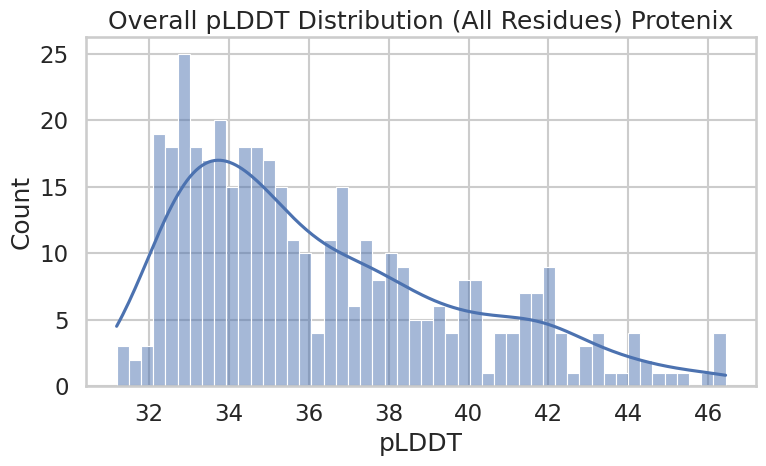

In [38]:
sns.set_theme(context="talk", style="whitegrid")
plt.figure(figsize=(8,5))
sns.histplot(residue_df['plddt'], bins=50, kde=True, color="#4C72B0")
plt.title("Overall pLDDT Distribution (All Residues) Protenix")
plt.xlabel("pLDDT")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


**Per-chain pLDDT distribution**

In [14]:
type(residue_df["chain_plddt"].iloc[0])

str

In [39]:
residue_df["chain_plddt"] = residue_df["chain_plddt"].apply(ast.literal_eval)

residue_df["chain_A_plddt"] = residue_df["chain_plddt"].apply(lambda x: x[0])
residue_df["chain_B_plddt"] = residue_df["chain_plddt"].apply(lambda x: x[1])
residue_df.head()


,complex_id,plddt,gpde,ptm,iptm,chain_gpde,chain_pair_gpde,chain_ptm,chain_iptm,chain_pair_iptm,chain_pair_iptm_global,chain_plddt,chain_pair_plddt,has_clash,disorder,ranking_score,num_recycles,chain_A_plddt,chain_B_plddt
0,binom16.pocket3pep98,32.475449,4.916508,0.196498,0.114255,"[0.8111537098884583, 4.816766738891602]","[[0.0, 15.716352462768555], [15.71635246276855...","[0.3735533654689789, 0.19666552543640137]","[0.11425471305847168, 0.11425471305847168]","[[0.0, 0.11425471305847168], [0.11425471305847...","[[0.0, 0.11425471305847168], [0.11425471305847...","[0.4575246572494507, 0.32008126378059387]","[[0.0, 0.3247544765472412], [0.324754476547241...",False,0.0,0.130703,10,0.457525,0.320081
1,paulafcfranklin.synth_rosetta_4,33.868034,4.797509,0.210093,0.129581,"[2.827415704727173, 4.580162525177002]","[[0.0, 15.087814331054688], [15.08781433105468...","[0.19939428567886353, 0.21189630031585693]","[0.1295805424451828, 0.1295805424451828]","[[0.0, 0.1295805424451828], [0.129580542445182...","[[0.0, 0.1295805424451828], [0.129580542445182...","[0.33482903242111206, 0.3389982581138611]","[[0.0, 0.33868032693862915], [0.33868032693862...",False,0.0,0.145683,10,0.334829,0.338998
2,paulafcfranklin.synth_rosetta_9,32.567631,4.977990,0.187675,0.108347,"[2.6595652103424072, 4.7867608070373535]","[[0.0, 16.396818161010742], [16.39681816101074...","[0.1546783745288849, 0.18797370791435242]","[0.10834743827581406, 0.10834743827581406]","[[0.0, 0.10834743827581406], [0.10834743827581...","[[0.0, 0.10834743827581406], [0.10834743827581...","[0.34139829874038696, 0.32415449619293213]","[[0.0, 0.3256763219833374], [0.325676321983337...",False,0.0,0.124213,10,0.341398,0.324154
3,keaun.GWFGVVFKADIAGVSEKVAIELSGGYEGSLTTPSGWNQ,31.383238,5.109601,0.201436,0.141212,"[2.322321653366089, 4.774051189422607]","[[0.0, 15.291553497314453], [15.29155349731445...","[0.12351859360933304, 0.20173001289367676]","[0.1412116289138794, 0.1412116289138794]","[[0.0, 0.1412116289138794], [0.141211628913879...","[[0.0, 0.1412116289138794], [0.141211628913879...","[0.2682507634162903, 0.31651586294174194]","[[0.0, 0.3138323724269867], [0.313832372426986...",False,0.0,0.153256,10,0.268251,0.316516
4,merlettaia.seq0v4,35.940678,4.625217,0.228335,0.195262,"[1.597744107246399, 4.838744163513184]","[[0.0, 16.51575469970703], [16.51575469970703,...","[0.634867250919342, 0.1905340701341629]","[0.19526216387748718, 0.19526216387748718]","[[0.0, 0.19526216387748718], [0.19526216387748...","[[0.0, 0.19526216387748718], [0.19526216387748...","[0.5747200846672058, 0.31718316674232483]","[[0.0, 0.3594067692756653], [0.359406769275665...",False,0.0,0.201877,10,0.574720,0.317183


In [18]:
type(residue_df["chain_A_plddt"].iloc[0])

numpy.float64

In [21]:
plot_df = residue_df.melt(
    value_vars=["chain_A_plddt", "chain_B_plddt"],
    var_name="chain",
    value_name="chain_plddt_value"
)

/tmp/ipykernel_1151512/867700927.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x="chain", y="chain_plddt_value", inner="quartile", palette="Set2", cut=0)


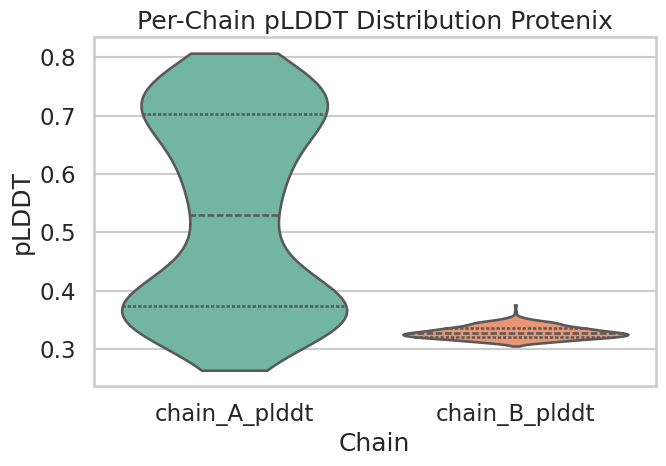

In [24]:
plt.figure(figsize=(7,5))
sns.violinplot(data=plot_df, x="chain", y="chain_plddt_value", inner="quartile", palette="Set2", cut=0)
plt.title("Per-Chain pLDDT Distribution Protenix")
plt.xlabel("Chain")
plt.ylabel("pLDDT")
plt.tight_layout()
plt.show()

**Merging of generated features CSV and binding CSV**

df1 = adaptyv_bio_df


df2 = features_df

In [40]:
output_csv = "/home/postyr/Assessing-AI-Scoring-Accuracy-for-De-Novo-Proteins/results/Protenix/merged_protenix_adaptyv_bio.csv"
join_type = "left"


def normalize_for_fuzzy_match(s):
    s = s.lower().strip()
    s = s.replace("=","")
    # replace separators like |, space, =, comma with underscore
    s = re.sub(r"[| :,]", "_", s)
    # remove any character that is NOT a letter, number, dot, or underscore
    s = re.sub(r"[^a-z0-9._]", "", s)
    # collapse multiple underscores
    s = re.sub(r"_+", "_", s)
    # optionally strip leading/trailing underscores
    s = s.strip("_")
    return s


df2 = residue_df.copy()
df1 = adaptyv_bio_df.copy()

df2["complex_id"] = df2["complex_id"].astype(str).str.strip().str.lower()
df1["name"] = df1["name"].astype(str).str.strip().str.lower()

df2["match_id"] = df2["complex_id"].apply(normalize_for_fuzzy_match)
df1["match_id"] = df1["name"].apply(normalize_for_fuzzy_match)


print("Overlapping normalized IDs:",
      len(set(df1["match_id"]).intersection(df2["match_id"])))

cols_from_df1 = [
    "name",
    "binding_strength",
    "binding",
    "expression",
    "pae_interaction",
    "design_models",
]

df1_sel = df1[cols_from_df1 + ["match_id"]]

merged = df1_sel.merge(
    df2,
    how=join_type,
    on="match_id"
)

# merged = merged.drop(columns=["match_id"])

merged.to_csv(output_csv, index=False)

print(f"Merged dataframe saved to {output_csv} with shape {merged.shape}")


Overlapping normalized IDs: 399
Merged dataframe saved to /home/postyr/Assessing-AI-Scoring-Accuracy-for-De-Novo-Proteins/results/Protenix/merged_protenix_adaptyv_bio.csv with shape (402, 26)


**Plots showing correlation between AF3 generated PAE, AdaptyvBio PAE and binding**


boolean
<BooleanArray>
[True, False, <NA>]
Length: 3, dtype: boolean
Binders: 55
Non‑binders: 325
=== Correlation Summary ===
Pearson(pae_interaction, interface_pae_AB) = r=0.551, p=6.8311115199743194e-31
Point-biserial(binding, pae_interaction) = r=-0.131, p=0.01139637171341879
Point-biserial(binding, interface_pae_AB) = r=-0.236, p=4.297752499839716e-06


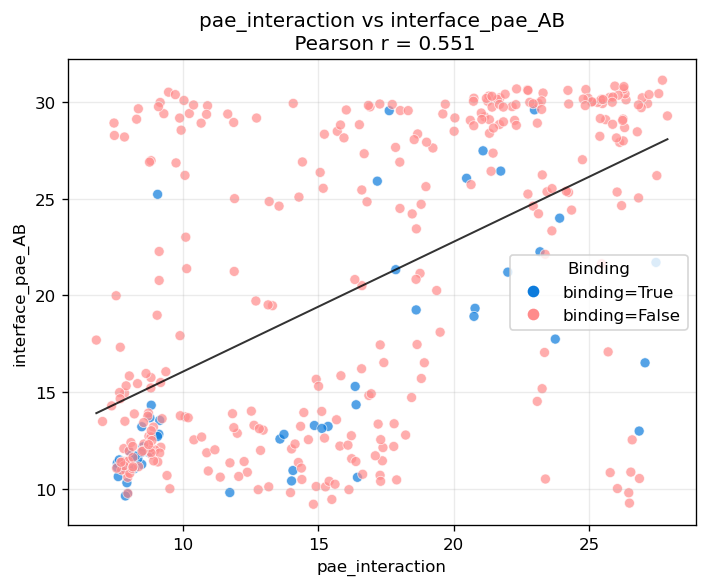

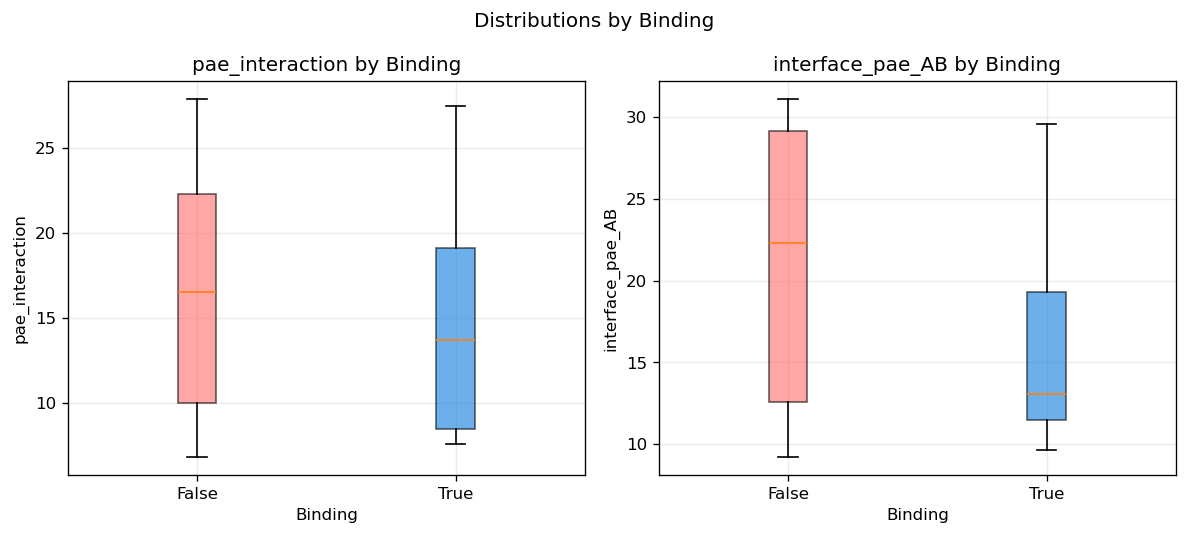

In [ ]:
# Try tu use SCiPy stats if available, but handle gracefully if not
try:
    from scipy import stats
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False

col_binding = "binding"
col_x = "pae_interaction"
col_y = "interface_pae_AB"

df = pd.read_csv(csv_path)

# Coerce binding to boolean

# Convert to lowercase string
binding_raw = df[col_binding].astype(str).str.strip().str.lower()

# Map correct values
df["binding_bool"] = binding_raw.map({"true": True, "false": False})

# "unknown", "nan", "none", etc. will now be NaN automatically.
# DO NOT fill NaN. We want unknowns removed via dropna() later.

# Convert explicitly to real booleans, keeping NaN
df["binding_bool"] = df["binding_bool"].astype("boolean")  # pandas BooleanDtype

# Numeric version for correlations (will be NaN where binding_bool is NaN)
df["binding01"] = df["binding_bool"].map({True: 1, False: 0})

print(df["binding_bool"].dtype)
print(df["binding_bool"].unique())
print(f"Binders: {df['binding_bool'].sum()}")
print(f"Non‑binders: {(df['binding_bool'] == False).sum()}")

# Coerce PAE columns to numerical

for c in [col_x, col_y]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

work = df[["binding_bool", "binding01", col_x, col_y]].dropna()

if work.empty:
    raise ValueError("After cleaning, no rows remain with non-missing binding/PAE values.")

def safe_pearson(x, y):
    if SCIPY_AVAILABLE:
        r, p = stats.pearsonr(x, y)
        return r, p
    r = np.corrcoef(x, y)[0, 1]
    return r, np.nan

r_xy, p_xy = safe_pearson(work[col_x].values, work[col_y].values)

def point_biserial(binary01, cont):
    if SCIPY_AVAILABLE:
        r, p = stats.pointbiserialr(binary01, cont)
        return r, p
    r = np.corrcoef(binary01, cont)[0, 1]
    return r, np.nan

r_bind_x, p_bind_x = point_biserial(work["binding01"].values, work[col_x].values)
r_bind_y, p_bind_y = point_biserial(work["binding01"].values, work[col_y].values)


print("=== Correlation Summary ===")
print(f"Pearson({col_x}, {col_y}) = r={r_xy:.3f}, p={p_xy if not np.isnan(p_xy) else 'N/A'}")
print(f"Point-biserial(binding, {col_x}) = r={r_bind_x:.3f}, p={p_bind_x if not np.isnan(p_bind_x) else 'N/A'}")
print(f"Point-biserial(binding, {col_y}) = r={r_bind_y:.3f}, p={p_bind_y if not np.isnan(p_bind_y) else 'N/A'}")

plt.rcParams["figure.dpi"] = 120

# scatter
fig1, ax1, = plt.subplots(figsize=(6,5))
colors = np.where(work["binding_bool"], "#0C7BDC", "#FF8B8B")
ax1.scatter(work[col_x], work[col_y], c=colors, alpha=0.7, edgecolors="white", linewidths=0.5)

# Regression line
xv = work[col_x].values
yv = work[col_y].values
if len(xv) >= 2:
    m, b = np.polyfit(xv, yv, 1)
    x_line = np.linspace(np.nanmin(xv), np.nanmax(xv), 100)
    y_line = m * x_line + b
    ax1.plot(x_line, y_line, color="black", linewidth=1.2, alpha=0.8, label="Linear fit")

# Legend
handles = [
    plt.Line2D([0], [0], color="#0C7BDC", marker="o", linestyle="", label="binding=True"),
    plt.Line2D([0], [0], color="#FF8B8B", marker="o", linestyle="", label="binding=False"),
]
ax1.legend(handles=handles, title="Binding")
ax1.set_title(f"{col_x} vs {col_y}\n Pearson r = {r_xy:.3f}")
ax1.set_xlabel(col_x)
ax1.set_ylabel(col_y)
ax1.grid(alpha=0.25)
fig1.tight_layout()
fig1.show()

# Boxplots 

work["binding_bool"] = work["binding_bool"].astype(bool)
work["binding_bool"] = work["binding_bool"] == True

fig2, axes = plt.subplots(1, 2, figsize=(10, 4.5), sharey=False)

for ax, c, title in zip(axes, [col_x, col_y], [f"{col_x} by Binding", f"{col_y} by Binding"]):
    vals_false = work.loc[~work["binding_bool"], c].values
    vals_true  = work.loc[work["binding_bool"], c].values
    bp = ax.boxplot([vals_false, vals_true],
                    tick_labels=["False", "True"],
                    patch_artist=True,
                    showfliers=True)    

    # colors
    colors_bp = ["#FF6B6B", "#0C7BDC"]
    for patch, color in zip(bp['boxes'], colors_bp):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    ax.set_title(title)
    ax.set_xlabel("Binding")
    ax.set_ylabel(c)
    ax.grid(alpha=0.25)


fig2.suptitle("Distributions by Binding")
fig2.tight_layout()
fig2.show()

**Will now extract the iptm values for each complex and use that to compare with binding status and interface PAE**

In [ ]:
# Path to folder with all the predictions.
root = "/home/postyr/Assessing-AI-Scoring-Accuracy-for-De-Novo-Proteins/results/AF3/AF3_run1_output"

records = []

for complex_folder in os.listdir(root):
    folder_path = os.path.join(root, complex_folder)
    if not os.path.isdir(folder_path):
        continue

# Find the summary json files with the iptm values.

    for fname in os.listdir(folder_path):
        if fname.endswith("_summary_confidences.json"):
            json_path = os.path.join(folder_path, fname)

# name is the folder name
            name = complex_folder

# Load JSON
            with open(json_path, "r") as f:
                data = json.load(f)

            records.append({
                "name": name,
                "iptm": data.get("iptm"),
                "ptm": data.get("ptm"),
                "fraction_disordered": data.get("fraction_disordered"),
                "ranking_score": data.get("ranking_score"),
                "chain_iptm": data.get("chain_iptm"),
                "chain_pair_iptm": data.get("chain_pair_iptm"),
                "chain_ptm": data.get("chain_ptm"),
            })

df_json = pd.DataFrame(records)
print(df_json.head())
print("Number of complexes found:", len(df_json))


                                                name  iptm   ptm  \
0                    paulafcfranklin.synth_rosetta_1  0.90  0.73   
1                                  merlettaia.seq0v3  0.13  0.60   
2                                      minji.lee.459  0.46  0.69   
3            spacecruiser42.d2_prompt_binder_t1.0_22  0.64  0.76   
4  deepsatflow.6aru_final_chain_a_domain_3_l147_s...  0.91  0.77   

   fraction_disordered  ranking_score    chain_iptm  \
0                 0.04           0.89    [0.9, 0.9]   
1                 0.02           0.23  [0.13, 0.13]   
2                 0.02           0.52  [0.46, 0.46]   
3                 0.05           0.69  [0.64, 0.64]   
4                 0.02           0.89  [0.91, 0.91]   

                chain_pair_iptm     chain_ptm  
0    [[0.66, 0.9], [0.9, 0.71]]  [0.66, 0.71]  
1  [[0.78, 0.13], [0.13, 0.68]]  [0.78, 0.68]  
2  [[0.72, 0.46], [0.46, 0.72]]  [0.72, 0.72]  
3  [[0.02, 0.64], [0.64, 0.77]]  [0.02, 0.77]  
4  [[0.87, 0.91], [0

boolean
<BooleanArray>
[True, False, <NA>]
Length: 3, dtype: boolean
Binders: 55
Non‑binders: 325
binding_bool unique: <BooleanArray>
[True, False, <NA>]
Length: 3, dtype: boolean
binding_bool
False    325
True      55
<NA>      22
Name: count, dtype: Int64


/tmp/ipykernel_1352604/2577582934.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


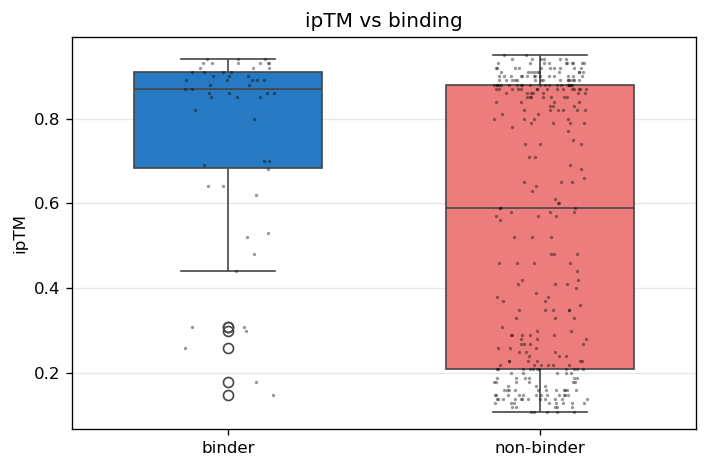

In [ ]:
og_df["name"] = og_df["name"].astype(str).str.strip().str.lower()
iptm_df["name"] = iptm_df["name"].astype(str).str.strip().str.lower()

df_full = og_df.merge(iptm_df, on="name", how="left")

df_full["binding_bool"] = binding_raw.map({"true": True, "false": False})

# "unknown", "nan", "none", etc. will now be NaN automatically.
# DO NOT fill NaN. We want unknowns removed via dropna() later.

# Convert explicitly to real booleans, keeping NaN
df_full["binding_bool"] = df_full["binding_bool"].astype("boolean")  # pandas BooleanDtype

# Numeric version for correlations (will be NaN where binding_bool is NaN)
df_full["binding01"] = df_full["binding_bool"].map({True: 1, False: 0})

print(df_full["binding_bool"].dtype)
print(df_full["binding_bool"].unique())
print(f"Binders: {df_full['binding_bool'].sum()}")
print(f"Non‑binders: {(df_full['binding_bool'] == False).sum()}")

print("binding_bool unique:", df_full["binding_bool"].unique())
print(df_full["binding_bool"].value_counts(dropna=False))

plot_df = df_full[df_full["binding_bool"].isin([True, False])].copy()
plot_df["binding_label"] = plot_df["binding_bool"].map({True: "binder", False: "non-binder"})

plt.figure(figsize=(6,4))
sns.boxplot(
    data=plot_df,
    x="binding_label",
    y="iptm",
    palette={"non-binder": "#FF6B6B", "binder": "#0C7BDC"},
    width=0.6
)
sns.stripplot(
    data=plot_df,
    x="binding_label",
    y="iptm",
    color="black",
    alpha=0.4,
    jitter=0.15,
    size=2
)
plt.title("ipTM vs binding")
plt.xlabel("")
plt.ylabel("ipTM")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()



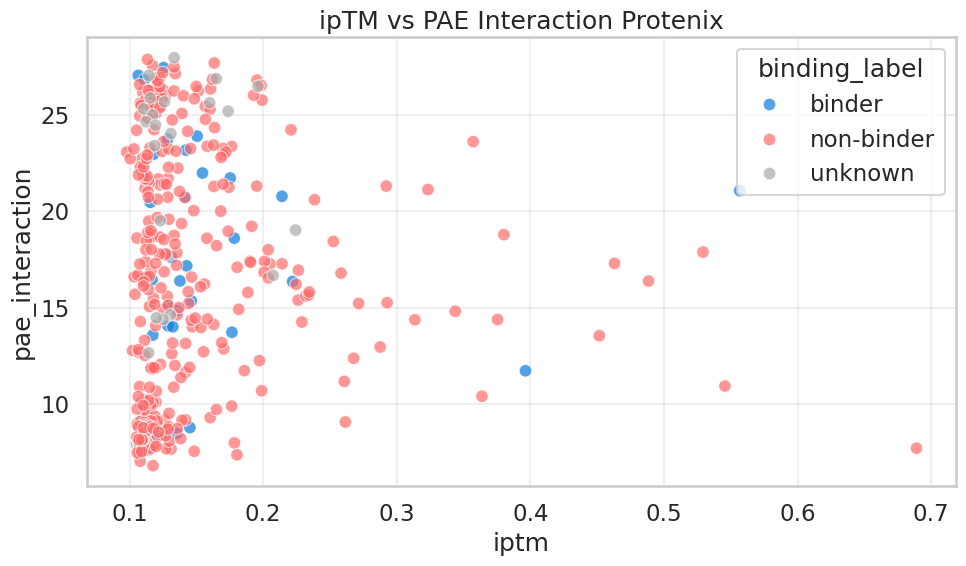

In [49]:
merged_csv = pd.read_csv("/home/postyr/Assessing-AI-Scoring-Accuracy-for-De-Novo-Proteins/results/Protenix/merged_protenix_adaptyv_bio.csv")

merged_csv["binding_label"] = merged_csv["binding"].map({
    "true": "binder",
    "false": "non-binder",
    "unknown": "unknown"  # optional, or assign a color
})

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=merged_csv,
    x="iptm",
    y="pae_interaction",
    hue="binding_label",
    palette={"binder": "#0C7BDC", "non-binder": "#FF6B6B", "unknown": "#AAAAAA"},
    alpha=0.7
)
plt.title("ipTM vs PAE Interaction Protenix")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

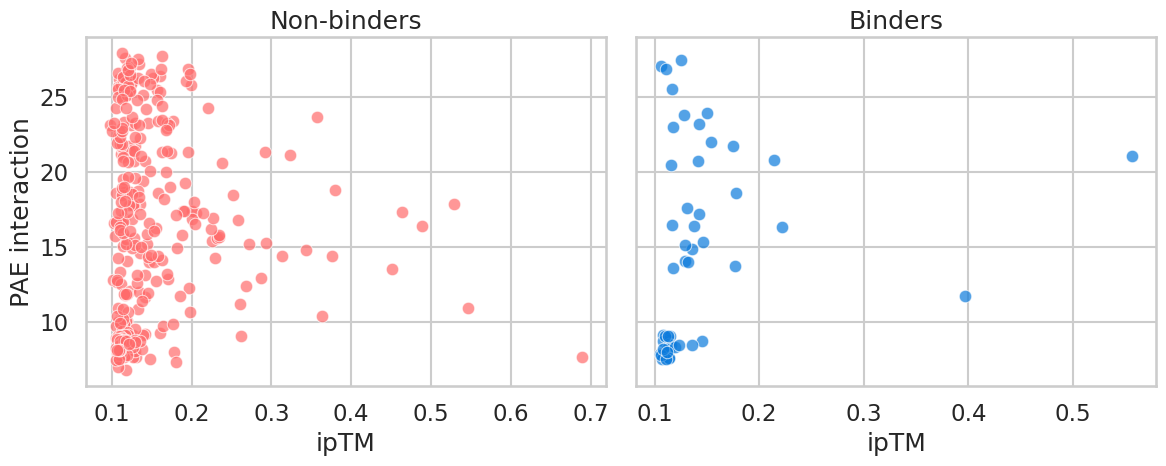

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Non-binders
sns.scatterplot(
    data=merged_csv[merged_csv["binding_label"] == "non-binder"],
    x="iptm",
    y="pae_interaction",
    color="#FF6B6B",
    alpha=0.7,
    ax=axes[0]
)
axes[0].set_title("Non-binders")
axes[0].set_xlabel("ipTM")
axes[0].set_ylabel("PAE interaction")

# Binders
sns.scatterplot(
    data=merged_csv[merged_csv["binding_label"] == "binder"],
    x="iptm",
    y="pae_interaction",
    color="#0C7BDC",
    alpha=0.7,
    ax=axes[1]
)
axes[1].set_title("Binders")
axes[1].set_xlabel("ipTM")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

Group stats (PEarson):
   binding_label         r              p
0        binder -0.978875   1.593855e-37
1    non-binder -0.978828  1.885182e-220


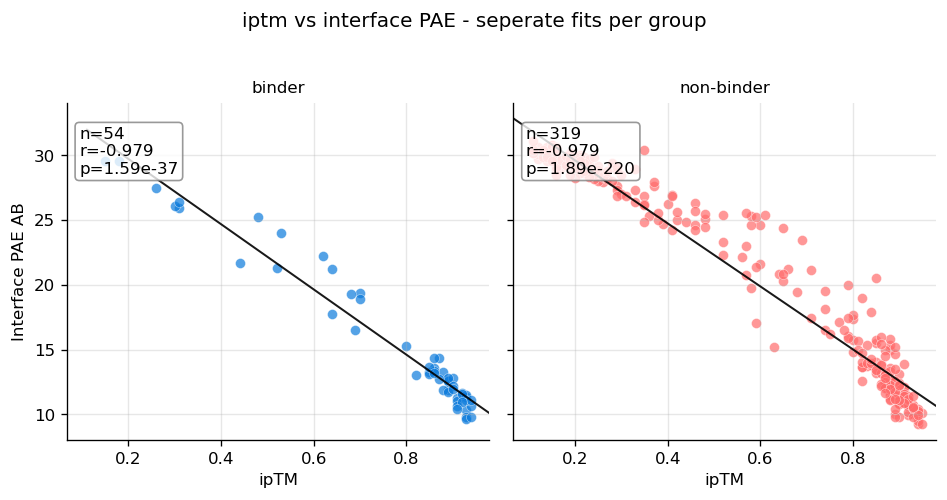

In [72]:

# Try to use SciPy for p-values; fall back gracefully if unavailable
try:
    from scipy import stats
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False

# -----------------------------
# 1) Prepare clean plotting data
# -----------------------------
plot_regr = df_full.loc[
    df_full["binding_bool"].isin([True, False]),
    ["binding_bool", "iptm", "interface_pae_AB"]
].copy()

# Coerce to numeric 

plot_regr["iptm"] = pd.to_numeric(plot_regr["iptm"], errors="coerce")
plot_regr["interface_pae_AB"] = pd.to_numeric(plot_regr["interface_pae_AB"], errors="coerce")
plot_regr = plot_regr.dropna(subset=["iptm", "interface_pae_AB"])

# Map to readabvle labels

plot_regr["binding_label"] = plot_regr["binding_bool"].map({True: "binder", False: "non-binder"})

# Function to compute Pearson r (group-wise)

def pearson_with_p(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    # Need at least 2 points for Pearson
    if np.sum(~np.isnan(x) & ~np.isnan(y)) < 2:
        return np.nan, np.nan
    if SCIPY_AVAILABLE:
        r, p = stats.pearsonr(x, y)
        return float(r), float(p)
    # Fallback to NumPy correlation without p-value
    r = np.corrcoef(x, y)[0, 1]
    return float(r), np.nan

# Pre-compute r, p per group for annotation later

stats_by_group = (
    plot_regr.groupby("binding_label", observed=True).apply(lambda g: pd.Series(pearson_with_p(g["iptm"], g["interface_pae_AB"]), index=["r", "p"])).reset_index()
)
print("Group stats (PEarson):\n", stats_by_group)

# Build FacetGrid with regression lines per group

palette = {"binder": "#0C7BDC", "non-binder": "#FF6B6B"}

g = sns.FacetGrid(plot_regr, col="binding_label", hue="binding_label", palette=palette, height=4, aspect=1)

# Scatter and regression line

g.map_dataframe(sns.regplot, x="iptm", y="interface_pae_AB", scatter=True, scatter_kws={"alpha":0.7, "edgecolor":"white", "linewidths":0.3}, line_kws={"color":"black", "lw": 1.2, "alpha": 0.9}, ci=None, truncate=False)

g.set_axis_labels("ipTM", "Interface PAE AB")
g.set_titles("{col_name}")
for ax in g.axes.flat:
    ax.grid(alpha=0.3)

# Annotate each facet with r, p and n

for ax, (label, subdf) in zip(g.axes.flat, plot_regr.groupby("binding_label", observed=True)):
    r, p = pearson_with_p(subdf["iptm"], subdf["interface_pae_AB"])
    n = len(subdf)
    if np.isnan(p):
        text = f"n={n}\nr={r:.3f}\np=N/A"
    else:
        # format P-values
        p_text = f"{p:.2e}" if p < 0.001 else f"{p:.3f}"
        text = f"n={n}\nr={r:.3f}\np={p_text}"
    # Place the text in the top-left corner inside the panel
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    x_text = xlim[0] + 0.03*(xlim[1]-xlim[0])
    y_text = ylim[1] - 0.07*(ylim[1]-ylim[0])
    ax.text(x_text, y_text, text, fontsize=10, va="top", ha="left", bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="gray", alpha=0.8))

plt.suptitle("iptm vs interface PAE - seperate fits per group", y=1.03, fontsize=12)
plt.tight_layout()
plt.show()

**Will now generate a new CSV with some more information and then merge that to get the TM-score values**

In [13]:
adb_metrics_df['name'] = adb_metrics_df['name'].astype(str).str.strip().str.lower().str.replace(" ", "_").str.replace("|", "_")


columns_to_keep = ["name", "id", "tm-scoreafdb50", "tm-scorecath50", "tm-scorepdb100"]

adb_metrics_df = adb_metrics_df[columns_to_keep]

# og_df = og_df.drop(columns=["binding"])

merged_df = (
    adb_metrics_df.merge(og_df, on="name", how="inner")
                .merge(iptm_df, on="name", how="inner")
                .sort_values("name", kind="mergesort")
                .reset_index(drop=True)
            )

merged_df.head()

,name,id,tm-scoreafdb50,tm-scorecath50,tm-scorepdb100,binding_strength,expression,pae_interaction,design_models,mean_plddt_A,...,interface_contact_sum,binding_bool,binding01,iptm,ptm,fraction_disordered,ranking_score,chain_iptm,chain_pair_iptm,chain_ptm
0,724928537.dbz6___a,mellow-cat-birch,0.92848,0.74337,0.96424,none,medium,25.083761,"[""Custom PLM""]",77.774728,...,48.92,False,0.0,0.15,0.61,0.02,0.25,"[0.15, 0.15]","[[0.82, 0.15], [0.15, 0.69]]","[0.82, 0.69]"
1,724928537.dbz7___a,rough-bat-willow,0.91914,0.72739,0.93867,unknown,none,25.686534,"[""Custom PLM""]",79.862089,...,43.55,NaN,NaN,0.23,0.63,0.02,0.32,"[0.23, 0.23]","[[0.82, 0.23], [0.23, 0.7]]","[0.82, 0.7]"
2,724928537.dbz8___a,wild-raven-granite,0.95274,0.76052,0.94269,none,high,20.738005,"[""Custom PLM""]",79.541509,...,62.84,False,0.0,0.22,0.60,0.02,0.30,"[0.22, 0.22]","[[0.82, 0.22], [0.22, 0.67]]","[0.82, 0.67]"
3,a.tucs.andrejs_tucs_seq1,steady-dove-granite,0.84721,0.30530,0.31035,weak,high,8.336581,"[""ProteinMPNN/LigandMPNN""]",85.432164,...,83.67,True,1.0,0.92,0.75,0.02,0.90,"[0.92, 0.92]","[[0.64, 0.92], [0.92, 0.74]]","[0.64, 0.74]"
4,a.tucs.andrejs_tucs_seq10,calm-panther-vine,0.88423,0.31623,0.31585,none,high,8.494685,"[""ProteinMPNN/LigandMPNN""]",84.835128,...,80.98,False,0.0,0.88,0.75,0.03,0.87,"[0.88, 0.88]","[[0.65, 0.88], [0.88, 0.74]]","[0.65, 0.74]"


**Should also take a look at the 3D structure of the best binders, and how AF3 predicts they look in the 3D space**